In [14]:
import pandas as pd

# Mostrar todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)


df = pd.read_csv('streamers2019_2025.csv')
df2 = pd.read_csv('streamers_tipocontenido.csv')
df19 = pd.read_csv('2019.csv')

In [15]:
def eda_basico(df):
    print("🔍 Primeras filas del DataFrame:")
    display(df.head())

    print("🔍 Últimas filas del DataFrame:")
    display(df.tail())

    print("📌 Filas Aleatorias:")
    display(df.sample(n=5))

    print("📐 Dimensiones:")
    print(f"{df.shape[0]} filas y {df.shape[1]} columnas\n")


    print("📊 Tipos de datos por columna:")
    display(df.dtypes.rename("Tipo").to_frame())

    print("📉 Descripción de columnas numéricas:")
    display(df.describe().T)

    print("🔤 Descripción de columnas categóricas:")
    display(df.describe(include=["O"]))

    print("🚫 Valores nulos por columna:")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if len(nulos) > 0:
        display(pd.DataFrame({
            "Nulos": nulos,
            "Porcentaje (%)": (nulos / len(df) * 100).round(2)
        }))
    else:
        print("No hay valores nulos.\n")

    print("🗑️ Columnas constantes:")
    constantes = [col for col in df.columns if df[col].nunique() == 1]
    if constantes:
        display(pd.DataFrame({
            "Columna": constantes,
            "Valor único": [df[col].unique()[0] for col in constantes],
            "Acción": ["Eliminar en Fase 2"] * len(constantes)
        }))
    else:
        print("No hay columnas constantes.\n")

    print("📎 Filas duplicadas:")
    dup_count = df.duplicated().sum()

    if dup_count > 0:
        print(f"Duplicadas: {dup_count}")
        print("Ejemplo de duplicados:")
        display(df[df.duplicated()].head())
    else:
        print("No hay filas duplicadas.\n")



In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Año                 350 non-null    int64
 1   Ranking             350 non-null    int64
 2   Streamer            350 non-null    str  
 3   Horas_vistas        350 non-null    int64
 4   Viewers_pico        350 non-null    int64
 5   Viewers_medios      350 non-null    int64
 6   Seguidores_total    350 non-null    int64
 7   Seguidores_ganados  350 non-null    int64
 8   País                350 non-null    str  
 9   Tipo_contenido      350 non-null    str  
 10  Género              350 non-null    str  
 11  Tipo_streamer       350 non-null    str  
dtypes: int64(7), str(5)
memory usage: 32.9 KB


In [16]:
eda_basico(df2)

🔍 Primeras filas del DataFrame:


,Año,Ranking,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados
0,2019,1,LVPes,España,Deportes,Esports,Organización,Organización,17333311,233009,10341,1085937,159288
1,2019,2,Rubius,España,Gaming,Variedad,Hombre,Individual,15737186,141108,20377,16429486,2107232
2,2019,3,ElmiilloR,España,Gaming,Variedad,Hombre,Individual,8655957,15817,4066,857587,117768
3,2019,4,elded,España,Gaming,Variedad,Hombre,Individual,7815386,23809,4916,5685307,658549
4,2019,5,ALKAPONE,España,Gaming,Variedad,Hombre,Individual,5367376,18977,4629,1156100,102992


🔍 Últimas filas del DataFrame:


,Año,Ranking,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados
345,2025,46,SirMaza,España,Gaming,Variedad,Hombre,Individual,3197966,11406,1788,479884,44246
346,2025,47,LUZU_TV,Argentina,Variedad,Just Chatting,Hombre,Individual,3184554,8929,1101,504951,47108
347,2025,48,Zeling,España,Gaming,Variedad,Mujer,Individual,3118245,9408,2405,628393,39630
348,2025,49,DiarioMARCA,España,Deportes,Periodismo,Organización,Organización,3091145,62592,9660,40858,1488
349,2025,50,GUANYAR,España,Gaming,Variedad,Hombre,Individual,3089552,26820,3671,625936,65733


📌 Filas Aleatorias:


...

C:\Users\usuar\AppData\Local\Temp\ipykernel_8888\1023191469.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["O"]))


,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer
count,350,350,350,300,350,350
unique,146,8,9,18,4,3
top,LVPes,España,Gaming,Variedad,Hombre,Individual
freq,7,231,217,168,241,268


🚫 Valores nulos por columna:


,Nulos,Porcentaje (%)
Subcategoria,50,14.29


🗑️ Columnas constantes:
No hay columnas constantes.

📎 Filas duplicadas:
No hay filas duplicadas.



In [ ]:
df2[df2["Subcategoria"].isna()]["Streamer"].value_counts()

In [26]:
df2[df2["Subcategoria"].isna()]["Streamer"].unique()

<StringArray>
[    'MarkiLokurasY',       'Evangelion0',      'Carritoskami',
            'Jac0b0',       'DuendePablo', 'VeteALaVersh_dkco',
   'RedRoyaleStream',             'SNEUX',            'Brakal',
          'XodaLive',        'iamdiamond',          'Llobeti4',
     'MarkitoNavaja',          'ReventXz',        'bytarifaaa',
          'SLAKUNTV',        'MrKeroro10',              'SUJA',
        'mrstiventc',            'MateoZ',           'Alliege',
         'LACOBRAAA',   'AgustinUnaplay8',     'Agustabell212',
            'AQUINO',      'CrystalMolly',           'AkuASMR',
     'MartinCirioOk',         'BaityBait',      'SergioFFerra',
          'BAXBEAST',              'M2cG',       'ElAbrahaham']
Length: 33, dtype: str

In [18]:
df2["Categoria_principal"].unique()

<StringArray>
[     'Deportes',        'Gaming',      'Variedad', 'Por verificar',
       'Eventos',        'Música', 'Just Chatting',            'TV',
          'ASMR']
Length: 9, dtype: str

In [9]:
#cambiamos el formato de los títulos de las columnas y algunas categorías
df.columns = df.columns.str.replace("_", " ")
for column in df.columns:
    if df[column].dtype == "str":
        df[column] = df[column].str.replace("_", " ")

#cambiamos los tipos de algunas columnas
df['Student ID'] = df['Student ID'].astype('str')
df.head()



,Student ID,Major Category,Year of Study,Pre Semester GPA,Weekly GenAI Hours,Primary Use Case,Prompt Engineering Skill,Tool Diversity,Paid Subscription,Traditional Study Hours,Perceived AI Dependency,Institutional Policy,Anxiety Level During Exams,Post Semester GPA,Skill Retention Score,Burnout Risk Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed With Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed With Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing Reading,Beginner,2,False,10.35,5,Strict Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed With Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed With Citation,4,3.798,100.00,Medium


📉 Histogramas de columnas numéricas:


array([[<Axes: title={'center': 'Pre Semester GPA'}>,
        <Axes: title={'center': 'Weekly GenAI Hours'}>,
        <Axes: title={'center': 'Tool Diversity'}>],
       [<Axes: title={'center': 'Traditional Study Hours'}>,
        <Axes: title={'center': 'Perceived AI Dependency'}>,
        <Axes: title={'center': 'Anxiety Level During Exams'}>],
       [<Axes: title={'center': 'Post Semester GPA'}>,
        <Axes: title={'center': 'Skill Retention Score'}>, <Axes: >]],
      dtype=object)

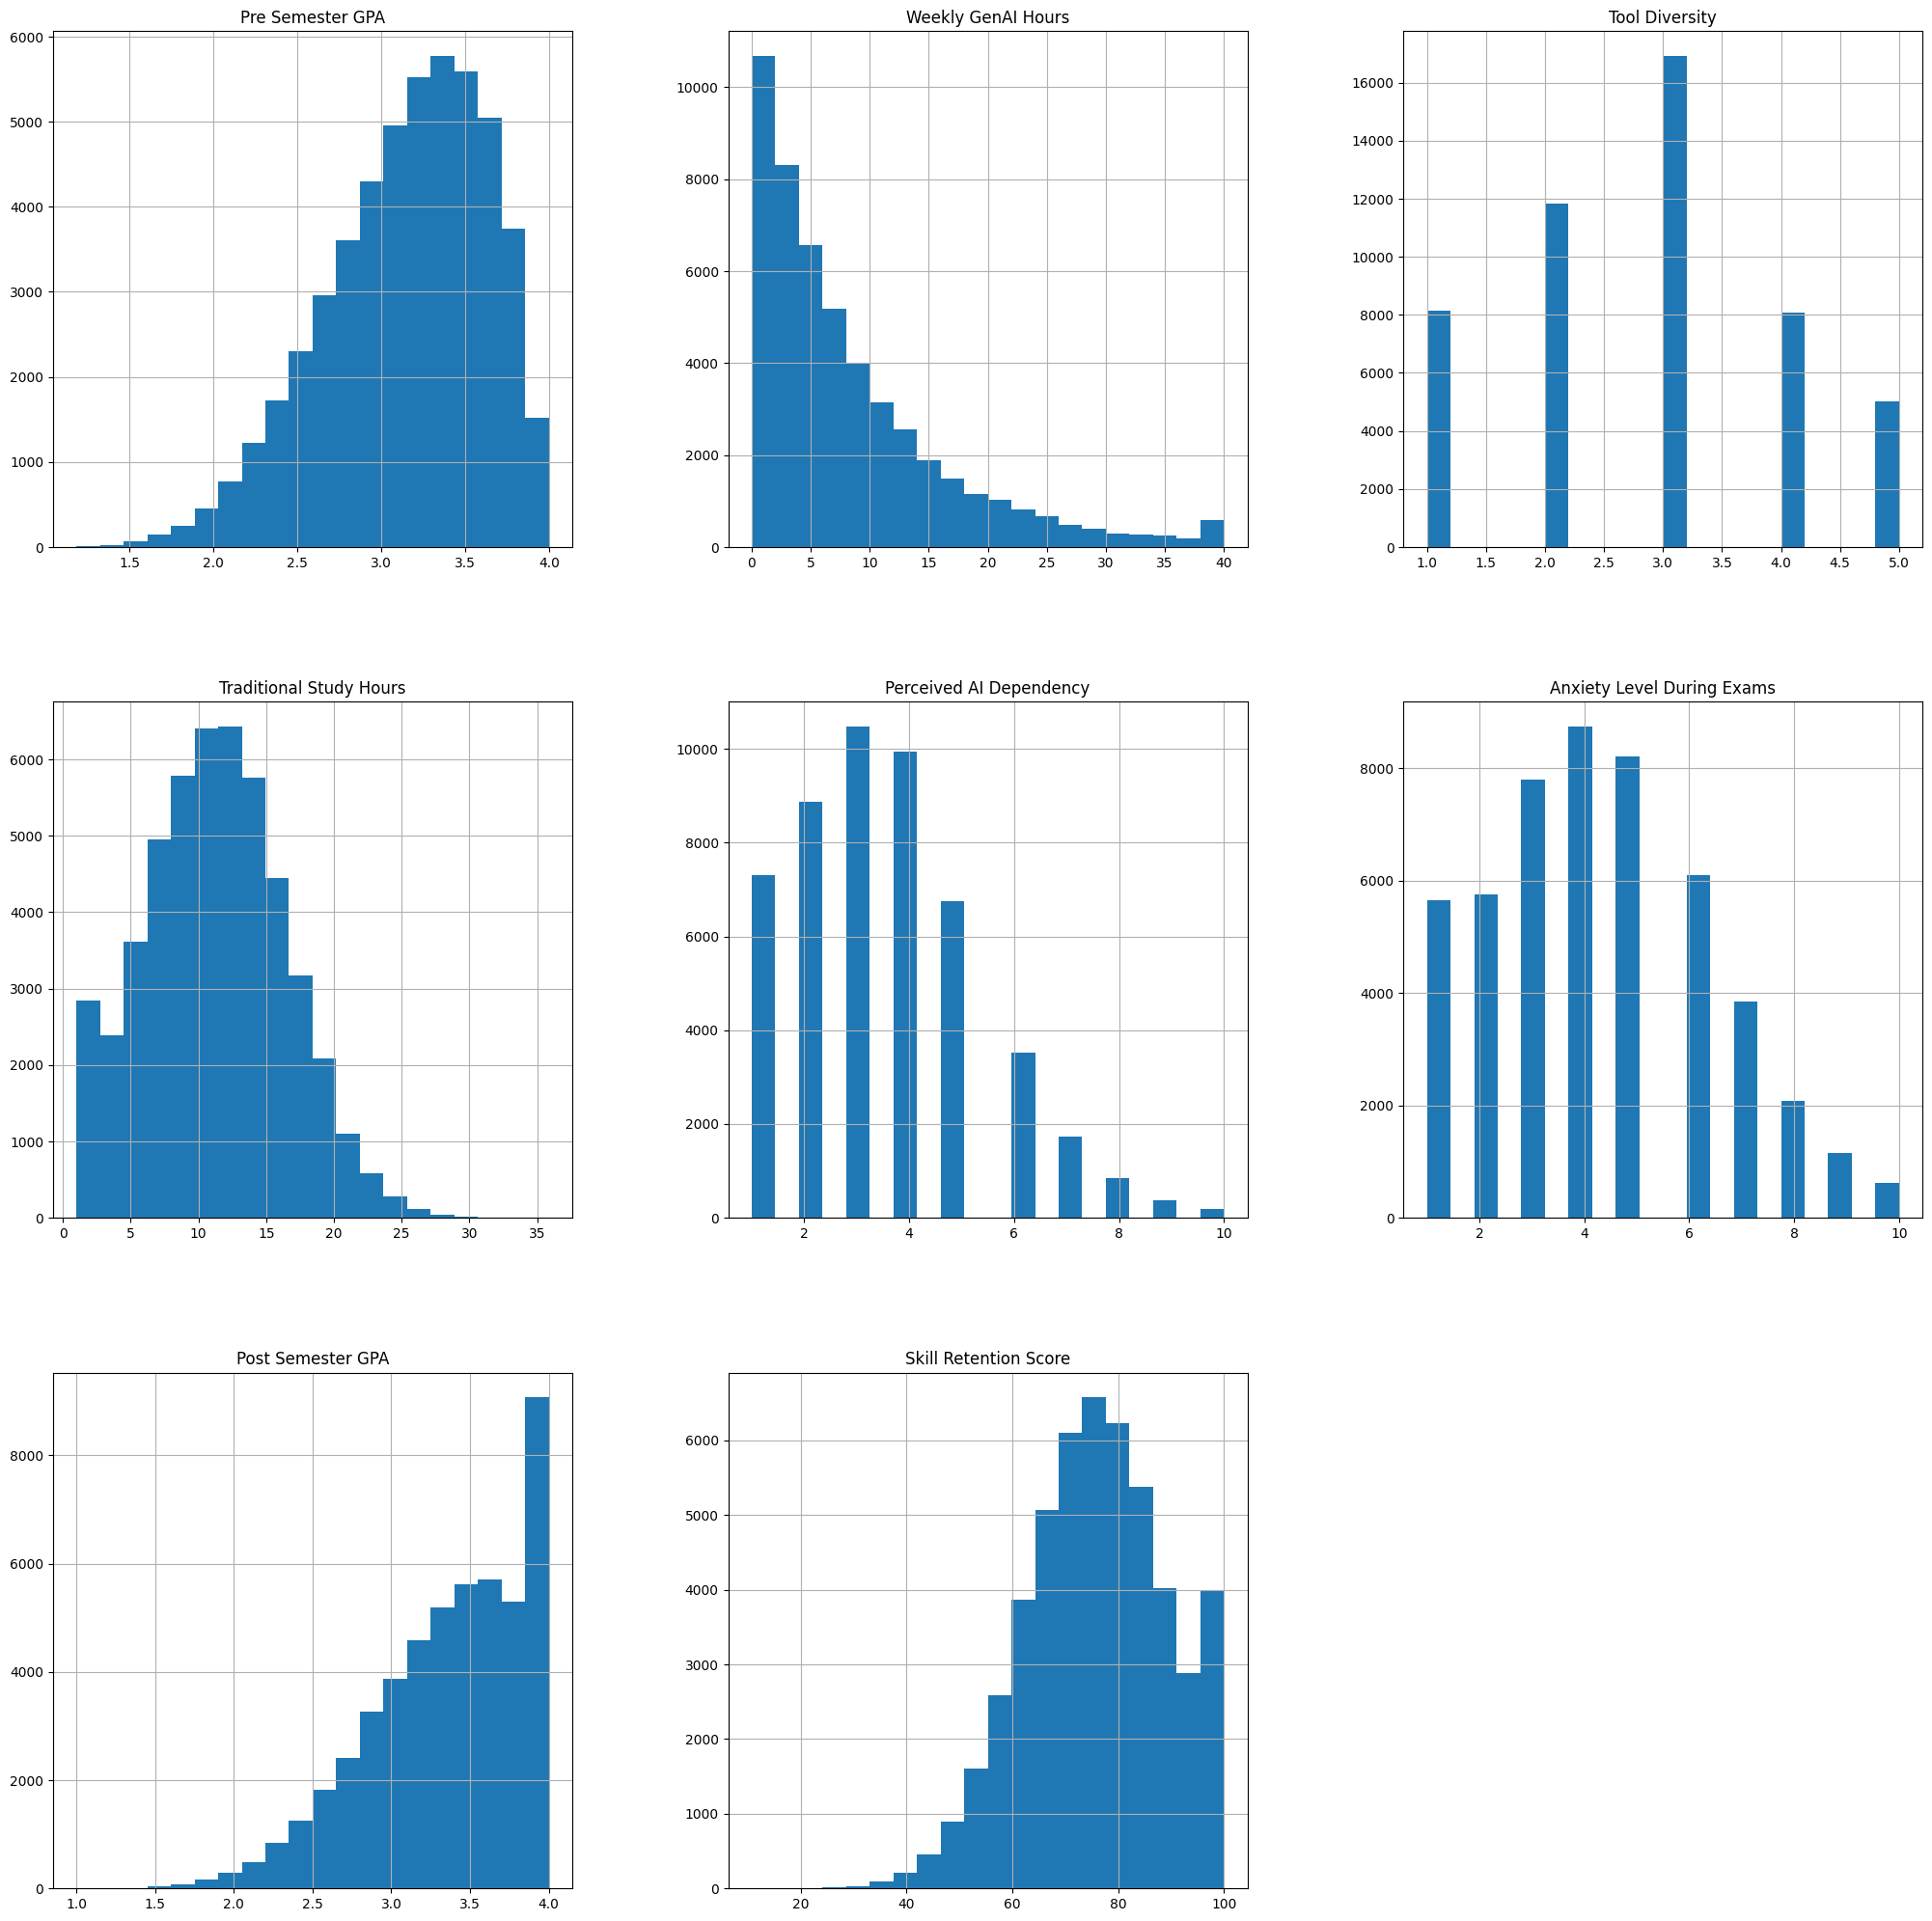

In [10]:
#miramos un poquito las variables numéricas con histogramas.
print("📉 Histogramas de columnas numéricas:")
df.hist(bins=20, figsize=(25,25))

In [11]:
#exportamos el csv definitivo
df1 = df.copy()
df1.to_csv("dataset_definitivo_impacto_ia.csv", index=False)